# NYC 보행 네트워크 다운로드 → GeoJSON 저장 (OSMnx)

- `network_type='walk'`로 뉴욕시 전체 보행 네트워크를 받아서 nodes / edges를 각각 GeoJSON으로 저장합니다.
- 뉴욕시 전체는 용량이 커서 다운로드에 수 분~수십 분 걸릴 수 있습니다. 한 번 받으면 캐시(`./cache`)에 남습니다.

In [7]:
import os
import osmnx as ox
import networkx as nx
import pandas as pd

print("osmnx version:", ox.__version__)

ox.settings.use_cache = True
ox.settings.log_console = True
ox.settings.requests_timeout = 600  # 큰 영역이라 타임아웃 넉넉하게

OUT_DIR = "Data/nyc_walk_network"
os.makedirs(OUT_DIR, exist_ok=True)

osmnx version: 2.0.2


## 1. 다운로드 방식 선택

- `MODE = 'city'`: 'New York City' 경계 하나로 한 번에 다운로드
- `MODE = 'borough'`: 5개 보로를 따로 받아서 합침 (한 번에 받다가 Overpass 타임아웃/메모리 문제가 나면 이쪽 추천)

In [8]:
MODE = "city"  # "city" 또는 "borough"

BOROUGHS = [
    "Manhattan, New York, USA",
    "Brooklyn, New York, USA",
    "Queens, New York, USA",
    "The Bronx, New York, USA",
    "Staten Island, New York, USA",
]

if MODE == "city":
    G = ox.graph_from_place(
        "New York City, New York, USA",
        network_type="drive",
        simplify=True,
        retain_all=False,   # True로 하면 끊어진 작은 컴포넌트(섬 등)도 유지
    )
else:
    graphs = []
    for b in BOROUGHS:
        print(f"Downloading: {b}")
        g = ox.graph_from_place(b, network_type="drive", simplify=True, retain_all=True)
        graphs.append(g)
    G = nx.compose_all(graphs)

print(f"nodes: {G.number_of_nodes():,}  |  edges: {G.number_of_edges():,}")

nodes: 55,303  |  edges: 139,185


## 2. (선택) GraphML로도 저장

나중에 네트워크 분석(최단경로 등)을 할 거면 그래프 구조가 보존되는 GraphML로도 저장해두는 게 편합니다.

In [9]:
ox.save_graphml(G, filepath=os.path.join(OUT_DIR, "nyc_drive.graphml"))

## 3. GeoDataFrame 변환 및 GeoJSON 저장

OSMnx의 edges에는 `osmid`, `highway`, `name` 등에 **list 값**이 섞여 있어서 그대로 GeoJSON으로 쓰면 에러가 나거나 타입이 깨집니다. list 컬럼을 문자열로 바꾼 뒤 저장합니다. GeoJSON은 EPSG:4326이어야 하므로 좌표계도 확인합니다.

In [10]:
nodes, edges = ox.graph_to_gdfs(G, nodes=True, edges=True)

# 인덱스를 컬럼으로 (nodes: osmid, edges: u, v, key)
nodes = nodes.reset_index()
edges = edges.reset_index()

def stringify_lists(gdf):
    gdf = gdf.copy()
    for col in gdf.columns:
        if col == gdf.geometry.name:
            continue
        if gdf[col].apply(lambda x: isinstance(x, (list, set, tuple))).any():
            gdf[col] = gdf[col].apply(
                lambda x: ";".join(map(str, x)) if isinstance(x, (list, set, tuple)) else x
            )
    return gdf

nodes = stringify_lists(nodes)
edges = stringify_lists(edges)

nodes = nodes.to_crs(epsg=4326)
edges = edges.to_crs(epsg=4326)

print(nodes.shape, edges.shape)
edges.head()

(55303, 9) (139185, 19)


,u,v,key,osmid,highway,lanes,maxspeed,name,oneway,ref,reversed,length,geometry,bridge,access,tunnel,width,junction,est_width
0,39076461,274283981,0,25161349,motorway,2,50 mph,Cross Island Parkway,True,CI,False,819.501666,"LINESTRING (-73.79475 40.78635, -73.79462 40.7...",NaN,NaN,NaN,NaN,NaN,NaN
1,39076461,42854803,0,25161578,motorway_link,1,NaN,NaN,True,NaN,False,268.144095,"LINESTRING (-73.79475 40.78635, -73.79332 40.7...",NaN,NaN,NaN,NaN,NaN,NaN
2,39076490,277672046,0,5699971,motorway_link,NaN,NaN,NaN,True,NaN,False,246.749804,"LINESTRING (-73.75709 40.76243, -73.75721 40.7...",NaN,NaN,NaN,NaN,NaN,NaN
3,39076490,277672005,0,1014007069,motorway,3,50 mph,Cross Island Parkway,True,CI,False,291.838695,"LINESTRING (-73.75709 40.76243, -73.75741 40.7...",NaN,NaN,NaN,NaN,NaN,NaN
4,39076504,462124701,0,618709517;618709515;5700693,motorway_link,1,NaN,NaN,True,NaN,False,433.149850,"LINESTRING (-73.74416 40.75347, -73.74453 40.7...",yes,NaN,NaN,NaN,NaN,NaN


In [11]:
nodes_path = os.path.join(OUT_DIR, "nyc_drive_nodes.geojson")
edges_path = os.path.join(OUT_DIR, "nyc_drive_edges.geojson")

nodes.to_file(nodes_path, driver="GeoJSON")
edges.to_file(edges_path, driver="GeoJSON")

for p in [nodes_path, edges_path]:
    print(f"{p}: {os.path.getsize(p) / 1e6:.1f} MB")

Data/nyc_walk_network/nyc_drive_nodes.geojson: 14.3 MB
Data/nyc_walk_network/nyc_drive_edges.geojson: 79.4 MB


## 4. 빠른 확인

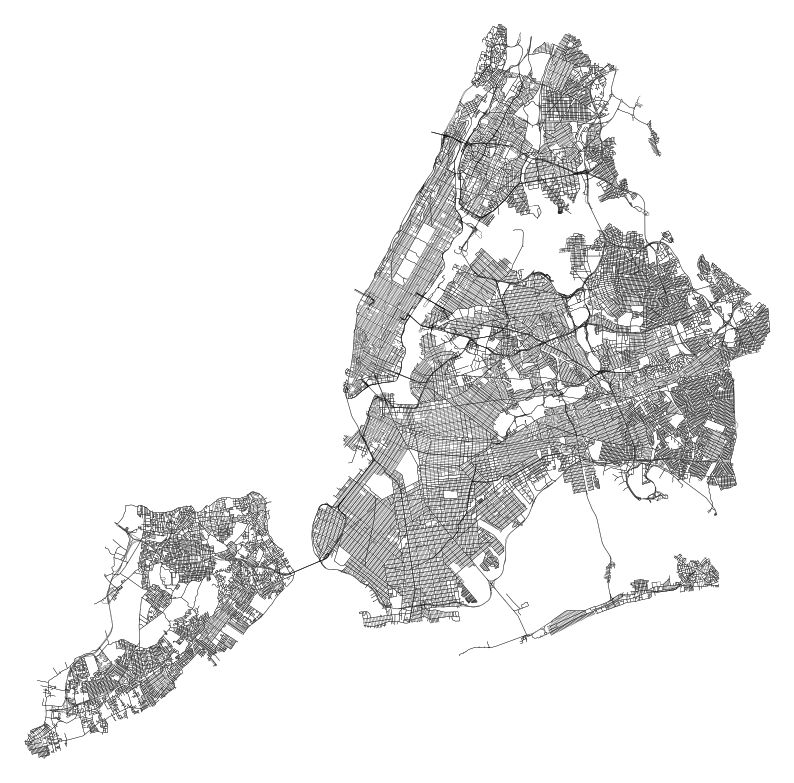

In [12]:
fig, ax = ox.plot_graph(G, node_size=0, edge_linewidth=0.2, bgcolor="white", edge_color="black", figsize=(10, 10))